# Classificação de flores Iris com MLP

Este notebook demonstra a criação de uma rede neural simples para classificar espécies de flores Iris utilizando a biblioteca TensorFlow/Keras.

O nosso objetivo é criar uma rede neural para classificação automática do tipo de flor Iris dado como entrada o comprimento e largura da sépala, comprimento e largura da pétala.

A rede deve dizer se trata-se de uma flor: iris setosa, iris versicolor, iris virginica.

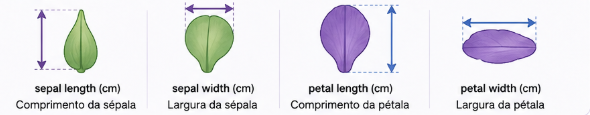

### 1. Preparação dos Dados
Nesta etapa, carregamos o dataset Iris e preparamos os dados para a rede neural.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

iris = load_iris()
caracteristicas = iris.data
especies = iris.target

display(pd.DataFrame(caracteristicas, columns=iris.feature_names).head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 1.1 Distribuição dos dados

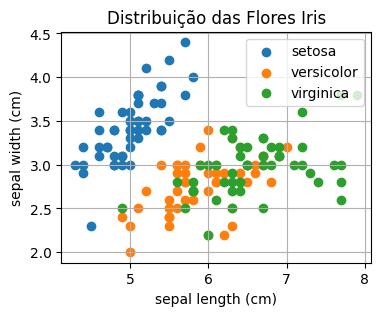

In [ ]:
plt.figure(figsize=(4, 3))
for i, nome_alvo in enumerate(iris.target_names):
    plt.scatter(caracteristicas[especies == i, 0], caracteristicas[especies == i, 1], label=nome_alvo)

plt.title("Distribuição das Flores Iris")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.grid(True)
plt.show()

### 1.3 Transformar espécies em formato numérico binário (One-Hot Encoding)

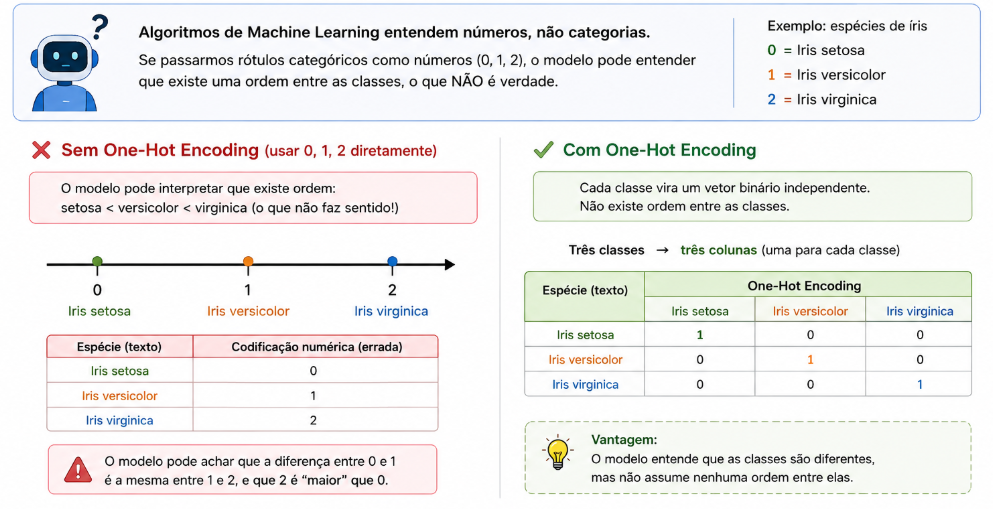

In [ ]:
encoder = OneHotEncoder(sparse_output=False)
especies_encoded = encoder.fit_transform(especies.reshape(-1, 1))

print("Exemplo de espécies codificadas:")
print(especies_encoded[:5])

Exemplo de espécies codificadas:
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


### 1.4 Dividir em treino (80%) e teste (20%)

In [ ]:
caract_treino, caract_teste, esp_treino, esp_teste = train_test_split(
    caracteristicas, especies_encoded, test_size=0.2, random_state=42
)

### 1.5 Normalizar os dados

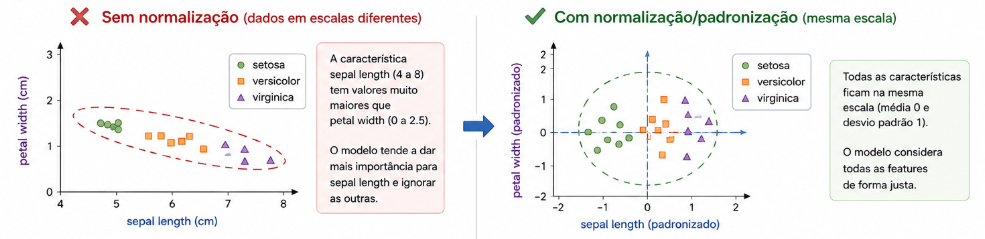

In [ ]:
padronizador = StandardScaler()
caract_treino = padronizador.fit_transform(caract_treino)
caract_teste = padronizador.transform(caract_teste)

### 2. Construção e Treinamento da MLP
Agora definimos a estrutura da rede neural e realizamos o treinamento.

In [ ]:

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])



In [ ]:

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['mse'])


historico = model.fit(caract_treino, esp_treino, epochs=100, batch_size=5, validation_split=0.1)


Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 1.0207 - mse: 0.2110 - val_loss: 1.0690 - val_mse: 0.2186
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9122 - mse: 0.1856 - val_loss: 0.9835 - val_mse: 0.1995
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8234 - mse: 0.1647 - val_loss: 0.9127 - val_mse: 0.1833
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7501 - mse: 0.1479 - val_loss: 0.8514 - val_mse: 0.1696
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6893 - mse: 0.1342 - val_loss: 0.8035 - val_mse: 0.1593
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6419 - mse: 0.1239 - val_loss: 0.7603 - val_mse: 0.1501
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5999 - mse: 0.1152 - val_loss: 0.7251 - val_mse: 0.1430
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5674 - mse: 0.1088 - val_loss: 0.6950 - val_mse: 0.1374
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.53

### 3. Visualização dos Resultados
Vamos plotar o gráfico de perda para verificar se o modelo aprendeu corretamente.

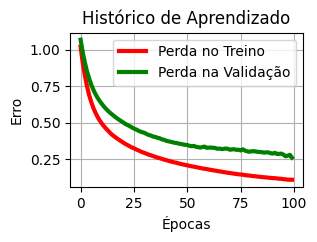

In [ ]:
plt.figure(figsize=(3,2))
plt.plot(historico.history['loss'], label='Perda no Treino', color='red', linewidth=3)
plt.plot(historico.history['val_loss'], label='Perda na Validação', color='green', linewidth=3)
plt.title('Histórico de Aprendizado')
plt.xlabel('Épocas')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
perda, erro = model.evaluate(caract_teste, esp_teste, verbose=0)
print(f"Erro MSE final no teste: {erro*100:.2f}%")

Erro MSE final no teste: 1.52%
